# M2 — Hyperparameter Sensitivity Analysis

**Mục tiêu:** Sweep alpha, sgd_steps, margin, batch_size, lifespan trên fake_behavior.csv + HGNN embeddings.

## Chuẩn bị trước khi chạy
Upload 3 files lên Colab (kéo thả vào file browser bên trái):
- `fake_behavior.csv` (từ `data/`)
- `article_embeddings_hgnn3.pt` (từ `src/models/`)
- `mlp_student.pt` (từ `src/models/`)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── 0. Kiểm tra GPU ──────────────────────────────────────────
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
# ── 1. Cài thư viện cần thiết ────────────────────────────────
# Colab đã có torch, pandas, numpy — chỉ cần tqdm
!pip install tqdm -q

In [17]:
# ── 2. Toàn bộ source code M2 (self-contained) ───────────────
import copy, io, base64, time, os, logging
from collections import OrderedDict
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logger = logging.getLogger(__name__)

# ── PersonalMLP64: MLP 64→64 hoạt động với HGNN embeddings ──
class PersonalMLP64(nn.Module):
    """Per-user MLP 64→64, initialized từ StudentMLP (remapped), adapt bằng triplet loss."""
    def __init__(self, base_state_dict=None):
        super().__init__()
        self.input_dim = 64
        self.output_dim = 64
        # Architecture: 64 → 128 → 64  (bottleneck nhỏ để không overfit)
        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
        )
        if base_state_dict is not None:
            self.load_state_dict(base_state_dict)

    def forward(self, x):
        return self.network(x)


class PersonalMLP64Factory:
    """Tạo PersonalMLP64 bằng cách deep-copy từ một base đã init."""
    def __init__(self, device="cpu"):
        self.device = device
        self._base = PersonalMLP64().to(device)
        # Khởi tạo với Xavier uniform để weights hợp lý
        for m in self._base.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def create(self, user_id):
        mlp = copy.deepcopy(self._base)
        mlp.user_id = user_id
        mlp.interaction_count = 0
        return mlp.to(self.device)


# ── TripletAdaptation64 ──────────────────────────────────────
class TripletAdaptation64:
    """Triplet loss adaptation cho PersonalMLP64 (64-dim embeddings)."""
    def __init__(self, sgd_steps=5, lr=1e-3, margin=1.0):
        self.sgd_steps = sgd_steps
        self.lr = lr
        self.margin = margin  # float('inf') → chỉ minimize dist_pos

    def adapt(self, mlp, positives: List[torch.Tensor], negatives: List[torch.Tensor]):
        """
        positives: list of 64-dim tensors (interacted articles)
        negatives: list of 64-dim tensors (not interacted)
        Modifies mlp in-place.
        """
        if not positives or not negatives:
            return 0.0
        mlp.train()
        optimizer = optim.SGD(mlp.parameters(), lr=self.lr, weight_decay=1e-6)

        h_pos = torch.stack(positives)   # [B_pos, 64]
        h_neg = torch.stack(negatives)   # [B_neg, 64]
        # anchor = centroid của positives
        h_wc = h_pos.mean(dim=0, keepdim=True)  # [1, 64]

        final_loss = 0.0
        for _ in range(self.sgd_steps):
            optimizer.zero_grad()
            proj_wc  = mlp(h_wc)    # [1, 64]
            proj_pos = mlp(h_pos)   # [B_pos, 64]
            proj_neg = mlp(h_neg)   # [B_neg, 64]

            dist_pos = ((proj_wc - proj_pos) ** 2).sum(dim=-1).mean()
            dist_neg = ((proj_wc - proj_neg) ** 2).sum(dim=-1).mean()

            if self.margin == float('inf'):
                loss = dist_pos
            else:
                loss = torch.clamp(dist_pos - dist_neg + self.margin, min=0.0)

            if loss.item() > 0:
                loss.backward()
                optimizer.step()
            final_loss = loss.item()

        mlp.eval()
        return final_loss


# ── UserState ────────────────────────────────────────────────
class UserState:
    def __init__(self, user_id="", alpha=0.5):
        self.user_id = user_id
        self.alpha = alpha
        self.ema_vector = None
        self.interaction_count = 0
        self.last_interaction_time = None  # datetime, dùng cho lifespan

    def update(self, emb, timestamp=None):
        emb = emb.detach()
        if self.ema_vector is None:
            self.ema_vector = emb.clone()
        else:
            self.ema_vector = (1 - self.alpha) * self.ema_vector + self.alpha * emb
        self.interaction_count += 1
        if timestamp is not None:
            self.last_interaction_time = timestamp
        return self.ema_vector

    def is_expired(self, current_time, lifespan_days):
        """Trả về True nếu user không có interaction trong lifespan_days ngày."""
        if self.last_interaction_time is None:
            return False
        delta = (current_time - self.last_interaction_time).total_seconds()
        return delta > lifespan_days * 86400


# ── CacheEntry & Lifecycle ───────────────────────────────────
class CacheEntry:
    def __init__(self, mlp, state):
        self.personal_mlp = mlp
        self.user_state = state
        self.interaction_batch = []  # list of 64-dim tensors


class MLPLifecycleManager:
    def __init__(self, factory, alpha=0.5, max_size=500):
        self.factory = factory
        self.alpha = alpha
        self.max_size = max_size
        self._cache = OrderedDict()
        self.stats = {"hits": 0, "misses": 0, "creates": 0, "evictions": 0}

    def get_or_create(self, user_id):
        if user_id in self._cache:
            self._cache.move_to_end(user_id)
            self.stats["hits"] += 1
            return self._cache[user_id]
        self.stats["misses"] += 1
        if len(self._cache) >= self.max_size:
            self._cache.popitem(last=False)
            self.stats["evictions"] += 1
        mlp = self.factory.create(user_id)
        state = UserState(user_id=user_id, alpha=self.alpha)
        entry = CacheEntry(mlp, state)
        self._cache[user_id] = entry
        self.stats["creates"] += 1
        return entry

    def delete_user(self, user_id):
        self._cache.pop(user_id, None)


# ── Metrics ──────────────────────────────────────────────────
def precision_at_k(recs, gt, k=10):
    if k == 0: return 0.0
    return len(set(recs[:k]) & set(gt)) / k

def recall_at_k(recs, gt, k=10):
    if not gt: return 0.0
    return len(set(recs[:k]) & set(gt)) / len(gt)

def f1_at_k(recs, gt, k=10):
    p = precision_at_k(recs, gt, k)
    r = recall_at_k(recs, gt, k)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

print("✓ Source code loaded (PersonalMLP64 + TripletAdaptation64 + lifespan-aware UserState)")


✓ Source code loaded (PersonalMLP64 + TripletAdaptation64 + lifespan-aware UserState)


In [18]:
# ── 3. Load artifacts ────────────────────────────────────────
def load_hgnn_embeddings(pt_path, device='cpu'):
    data = torch.load(pt_path, map_location=device, weights_only=True)
    matrix = data['embeddings'].to(device)   # [N, 64]
    id2idx  = data['id2idx']
    result = {}
    for aid10, idx in id2idx.items():
        result[str(int(aid10))] = matrix[idx]  # 10-digit → 9-digit
    print(f'✓ Loaded {len(result)} HGNN embeddings  shape={matrix.shape}  device={matrix.device}')
    return result


def load_behavior(csv_path, max_users=None):
    df = pd.read_csv(csv_path)
    df['article_id'] = df['article_id'].astype(str)
    df['customer_id'] = df['customer_id'].astype(str)
    df['t_dat'] = pd.to_datetime(df['t_dat'])
    df = df.sort_values('t_dat')
    if max_users:
        top = df['customer_id'].value_counts().head(max_users).index
        df = df[df['customer_id'].isin(top)].copy()
    print(f'✓ Behavior: {len(df):,} rows | {df["customer_id"].nunique():,} users | {df["article_id"].nunique():,} articles')
    return df


hgnn_emb = load_hgnn_embeddings('/content/drive/MyDrive/RS/article_embeddings_hgnn3.pt', device=DEVICE)
behavior_df = load_behavior('/content/drive/MyDrive/RS/data/fake_behavior.csv')

# Move all embeddings to GPU tensor for fast batch KNN
ALL_IDS = list(hgnn_emb.keys())
ALL_EMB = torch.stack([hgnn_emb[a] for a in ALL_IDS])  # [N, 64] on GPU
print(f'✓ Embedding matrix: {ALL_EMB.shape}  on {ALL_EMB.device}')

# Factory dùng PersonalMLP64 (64→128→64), không cần mlp_student.pt
factory = PersonalMLP64Factory(device=DEVICE)
print(f'✓ PersonalMLP64Factory ready (64→128→64, Xavier init)')


✓ Loaded 19278 HGNN embeddings  shape=torch.Size([19278, 64])  device=cuda:0
✓ Behavior: 2,123,501 rows | 72,248 users | 19,284 articles
✓ Embedding matrix: torch.Size([19278, 64])  on cuda:0
✓ PersonalMLP64Factory ready (64→128→64, Xavier init)


In [19]:
# ── 4. GPU-accelerated recommender + run_config đầy đủ ───────

@torch.no_grad()
def get_top_k_mlp(query_vec, mlp, k=11, exclude_id=None):
    """
    KNN sau khi project toàn bộ embedding matrix qua Personal MLP.
    query_vec: 64-dim EMA (đã được project qua MLP khi update).
    """
    # Project toàn bộ corpus qua MLP của user này
    mlp.eval()
    projected = mlp(ALL_EMB)          # [N, 64]
    q = query_vec.unsqueeze(0)        # [1, 64]
    dists = torch.cdist(q, projected).squeeze(0)  # [N]
    _, idx = dists.topk(k, largest=False)
    recs = [ALL_IDS[i] for i in idx.tolist()]
    if exclude_id:
        recs = [r for r in recs if r != exclude_id]
    return recs[:k-1]


def run_config(behavior_df, alpha, sgd_steps, margin, batch_size, lifespan_days,
               max_users=500, k=10, gt_t=12):
    """
    Chạy 1 config với:
    - EMA update qua Personal MLP projection
    - Triplet SGD adaptation mỗi batch_size interactions
    - Lifespan: reset user state nếu không có interaction trong lifespan_days ngày
    - Recommendation: KNN trên MLP-projected corpus
    """
    top_users = behavior_df['customer_id'].value_counts().head(max_users).index
    df = behavior_df[behavior_df['customer_id'].isin(top_users)]

    lifecycle = MLPLifecycleManager(factory, alpha=alpha, max_size=max_users + 50)
    adaptation = TripletAdaptation64(sgd_steps=sgd_steps, lr=1e-3, margin=margin)

    all_p, all_r, all_f1 = [], [], []
    t0 = time.time()

    for user_id, user_df in df.groupby('customer_id'):
        articles  = user_df['article_id'].tolist()
        timestamps = user_df['t_dat'].tolist()

        entry = lifecycle.get_or_create(user_id)

        for i, (aid, ts) in enumerate(zip(articles, timestamps)):
            if aid not in hgnn_emb:
                continue

            # ── Lifespan check: reset nếu user "nguội" quá lâu ──────
            if entry.user_state.is_expired(ts, lifespan_days):
                # Xóa cache → tạo lại entry mới (reset MLP + EMA)
                lifecycle.delete_user(user_id)
                entry = lifecycle.get_or_create(user_id)

            raw_emb = hgnn_emb[aid]  # 64-dim HGNN

            # ── EMA update: project qua Personal MLP trước ───────────
            with torch.no_grad():
                mlp_proj = entry.personal_mlp(raw_emb.unsqueeze(0)).squeeze(0)  # [64]
            entry.user_state.update(mlp_proj, timestamp=ts)

            # ── Tích lũy batch cho triplet adaptation ────────────────
            entry.interaction_batch.append(raw_emb)

            if len(entry.interaction_batch) >= batch_size:
                # Positives = raw HGNN embeddings vừa tương tác
                positives = entry.interaction_batch[:]
                # Negatives = random articles không trong batch
                neg_pool = [hgnn_emb[a] for a in articles
                            if a in hgnn_emb and a not in set(articles[max(0,i-batch_size):i+1])]
                if not neg_pool:
                    # fallback: lấy từ toàn corpus
                    neg_pool = [ALL_EMB[j] for j in torch.randperm(len(ALL_IDS))[:len(positives)]]
                negatives = neg_pool[:len(positives)]
                adaptation.adapt(entry.personal_mlp, positives, negatives)
                entry.interaction_batch = []

            # ── Evaluate: recommend từ MLP-projected EMA ─────────────
            future = [a for a in articles[i+1:i+1+gt_t] if a in hgnn_emb]
            if not future:
                continue

            ema = entry.user_state.ema_vector
            recs = get_top_k_mlp(ema, entry.personal_mlp, k=k+1, exclude_id=aid)

            all_p.append(precision_at_k(recs, future, k))
            all_r.append(recall_at_k(recs, future, k))
            all_f1.append(f1_at_k(recs, future, k))

    n = len(all_p)
    scale = 1e4
    return {
        'alpha': alpha, 'sgd_steps': sgd_steps, 'margin': margin,
        'batch_size': batch_size, 'lifespan_days': lifespan_days,
        'precision_e4': round(np.mean(all_p) * scale, 2) if n else 0.0,
        'recall_e4':    round(np.mean(all_r) * scale, 2) if n else 0.0,
        'f1_e4':        round(np.mean(all_f1) * scale, 2) if n else 0.0,
        'n_evals': n,
        'elapsed_s': round(time.time() - t0, 1),
    }


# Quick smoke test
row = run_config(behavior_df, alpha=0.5, sgd_steps=5, margin=1.0, batch_size=5,
                 lifespan_days=14, max_users=10)
print(f"Smoke test → P@10={row['precision_e4']}  R@10={row['recall_e4']}  F1@10={row['f1_e4']}  n={row['n_evals']}  t={row['elapsed_s']}s")


Smoke test → P@10=43.39  R@10=38.88  F1@10=39.84  n=5139  t=23.0s


In [20]:
# ── 5. Sensitivity sweep ─────────────────────────────────────
# Điều chỉnh MAX_USERS theo RAM/thời gian:
#   50  users → ~2  phút  (smoke)
#   200 users → ~8  phút
#   500 users → ~20 phút
MAX_USERS = 200

SWEEP = {
    'alpha':         [0.1, 0.3, 0.5, 0.7, 1.0],
    'sgd_steps':     [1, 5, 20, 50],
    'margin':        [0.1, 1.0, 10.0, float('inf')],
    'batch_size':    [1, 3, 5, 9],
    'lifespan_days': [1, 7, 14, 21],
}

# Default phù hợp với 64-dim space (margin nhỏ hơn so với 512-dim)
DEFAULTS = dict(alpha=0.5, sgd_steps=5, margin=1.0, batch_size=5, lifespan_days=14)

results = []
total_configs = sum(len(v) for v in SWEEP.values())
print(f'Total configs: {total_configs}  |  max_users={MAX_USERS}')
print('Lưu ý: mỗi config chạy SGD adaptation thật sự + lifespan enforcement\n')

with tqdm(total=total_configs, desc='Sweeping') as pbar:
    for param, values in SWEEP.items():
        for val in values:
            cfg = dict(DEFAULTS)
            cfg[param] = val
            row = run_config(behavior_df, max_users=MAX_USERS, **cfg)
            row['sweep_param'] = param
            results.append(row)
            pbar.set_postfix({
                'param': f'{param}={val}',
                'F1': row['f1_e4'],
                't': f"{row['elapsed_s']}s"
            })
            pbar.update(1)

results_df = pd.DataFrame(results)
print(f'\n✓ Done! {len(results_df)} configs evaluated')


Total configs: 21  |  max_users=200
Lưu ý: mỗi config chạy SGD adaptation thật sự + lifespan enforcement



Sweeping:   0%|          | 0/21 [00:00<?, ?it/s]


✓ Done! 21 configs evaluated


In [21]:
# ── 6. In kết quả ─────────────────────────────────────────────
for param in SWEEP:
    sub = results_df[results_df['sweep_param'] == param][
        [param, 'precision_e4', 'recall_e4', 'f1_e4', 'n_evals', 'elapsed_s']
    ].reset_index(drop=True)
    print(f'\n=== {param} ===')
    print(sub.to_string(index=False))


=== alpha ===
 alpha  precision_e4  recall_e4  f1_e4  n_evals  elapsed_s
   0.1         41.20      34.97  37.68    54704      194.4
   0.3         46.71      40.53  42.86    54704      191.9
   0.5         51.15      44.20  46.86    54704      191.6
   0.7         52.04      44.63  47.66    54704      190.9
   1.0         49.70      43.01  45.59    54704      191.5

=== sgd_steps ===
 sgd_steps  precision_e4  recall_e4  f1_e4  n_evals  elapsed_s
         1         52.46      45.31  48.07    54704       87.1
         5         51.15      44.20  46.86    54704      190.5
        20         49.45      42.60  45.32    54704      478.6
        50         48.53      41.84  44.48    54704      862.8

=== margin ===
 margin  precision_e4  recall_e4  f1_e4  n_evals  elapsed_s
    0.1         52.88      45.58  48.44    54704      146.4
    1.0         51.15      44.20  46.86    54704      191.5
   10.0         50.78      43.84  46.51    54704      194.7
    inf         53.10      45.89  48.66  

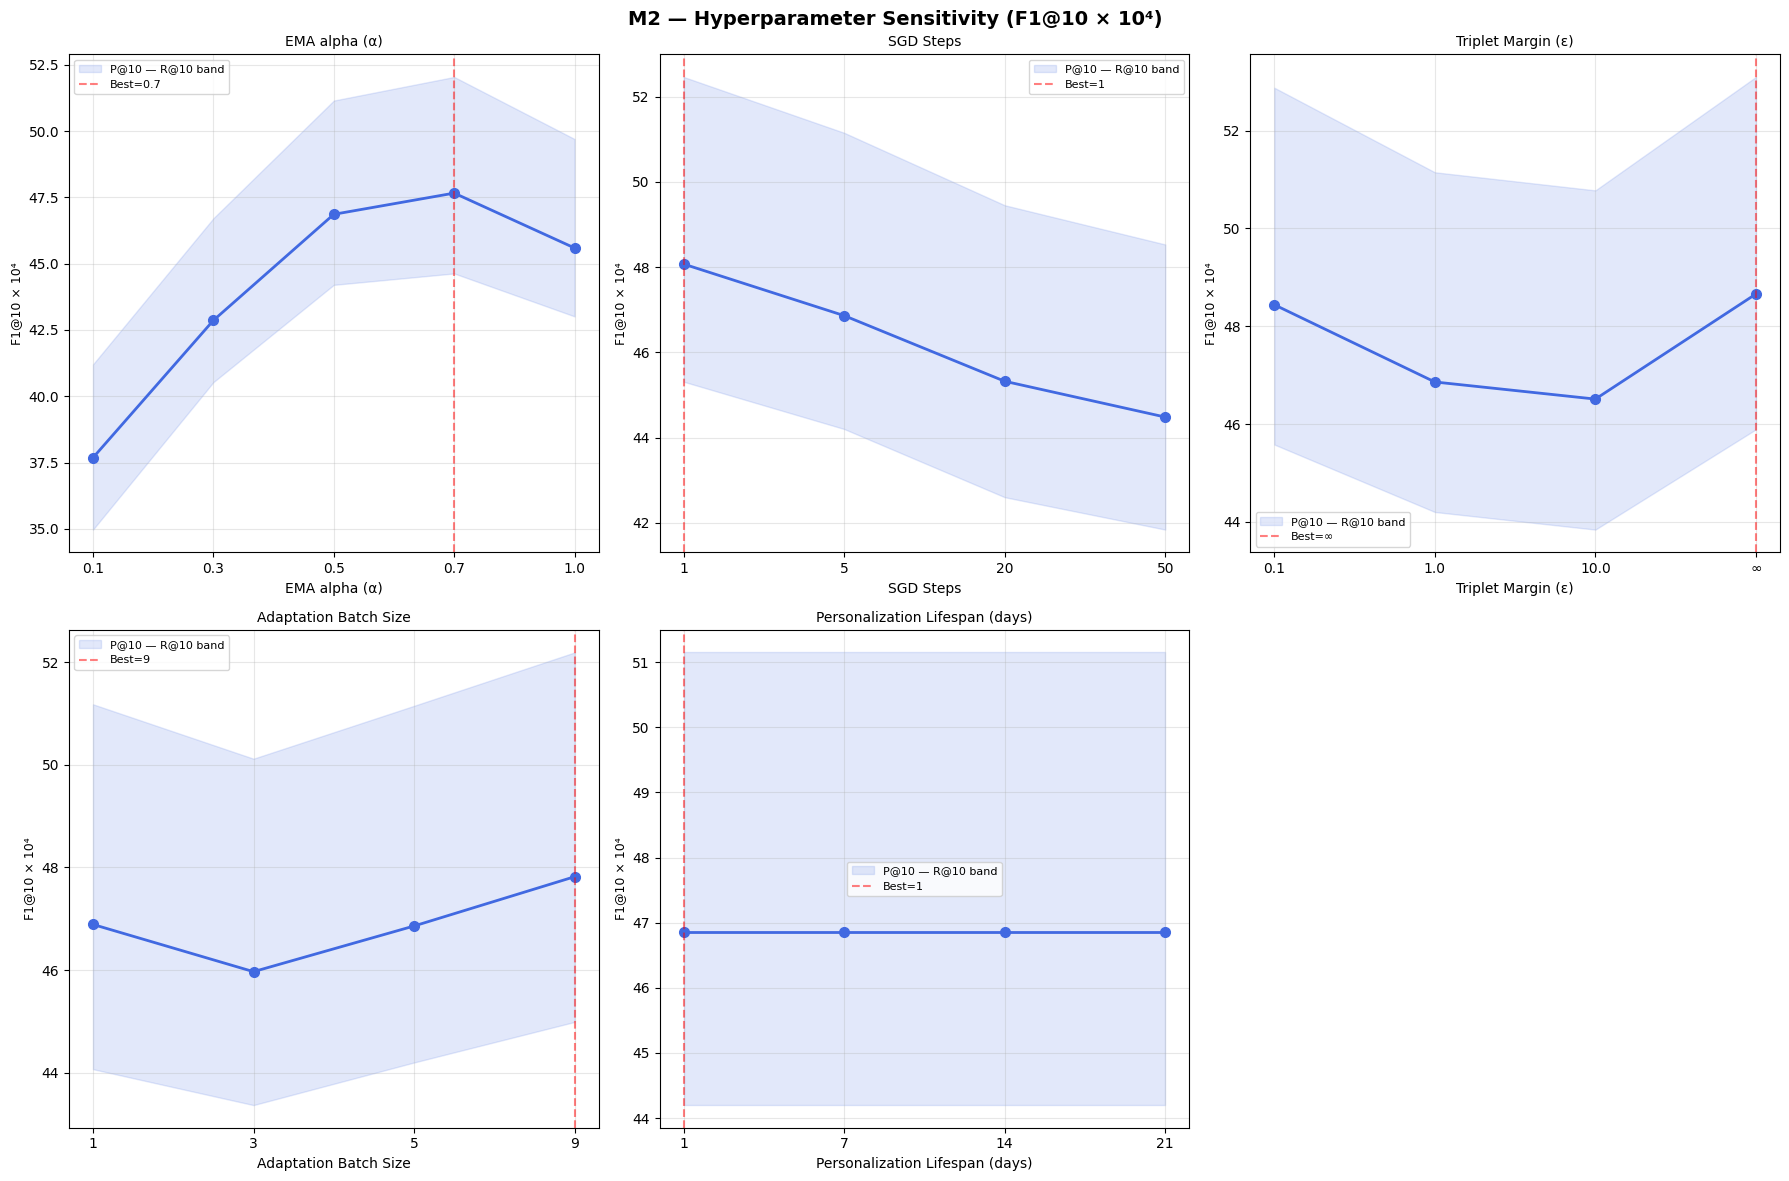

✓ Saved: sensitivity_plots.png


In [22]:
# ── 7. Vẽ plots ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 12))
fig.suptitle('M2 — Hyperparameter Sensitivity (F1@10 × 10⁴)', fontsize=14, fontweight='bold')

param_labels = {
    'alpha':         'EMA alpha (α)',
    'sgd_steps':     'SGD Steps',
    'margin':        'Triplet Margin (ε)',
    'batch_size':    'Adaptation Batch Size',
    'lifespan_days': 'Personalization Lifespan (days)',
}

for i, (param, label) in enumerate(param_labels.items(), 1):
    ax = fig.add_subplot(2, 3, i)
    sub = results_df[results_df['sweep_param'] == param].copy()

    # Handle inf margin for plotting
    x_vals = sub[param].replace(float('inf'), 999).tolist()
    x_labels = [str(v) if v != float('inf') else '∞' for v in sub[param].tolist()]

    ax.plot(range(len(x_vals)), sub['f1_e4'], 'o-', color='royalblue', linewidth=2, markersize=7)
    ax.fill_between(range(len(x_vals)),
                    sub['precision_e4'], sub['recall_e4'],
                    alpha=0.15, color='royalblue', label='P@10 — R@10 band')
    ax.set_xticks(range(len(x_vals)))
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('F1@10 × 10⁴', fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.grid(True, alpha=0.3)

    # Mark best
    best_idx = sub['f1_e4'].idxmax()
    best_pos = sub.index.get_loc(best_idx)
    ax.axvline(best_pos, color='red', linestyle='--', alpha=0.5, label=f'Best={x_labels[best_pos]}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RS/sensitivity_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: sensitivity_plots.png')

In [23]:
# ── 8. Lưu CSV & download ─────────────────────────────────────
results_df.to_csv('/content/drive/MyDrive/RS/sensitivity.csv', index=False)
print('✓ Saved: sensitivity.csv')

# Best config theo F1
best = results_df.loc[results_df['f1_e4'].idxmax()]
print(f'\n🏆 Best overall config:')
print(best[['alpha','sgd_steps','margin','batch_size','lifespan_days','f1_e4']].to_string())

# Download files
try:
    from google.colab import files
    files.download('/content/drive/MyDrive/RS/sensitivity.csv')
    files.download('/content/drive/MyDrive/RS/sensitivity_plots.png')
    print('✓ Download started')
except ImportError:
    print('(Not in Colab — files saved locally)')

✓ Saved: sensitivity.csv

🏆 Best overall config:
alpha              0.5
sgd_steps            5
margin             inf
batch_size           5
lifespan_days       14
f1_e4            48.66


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


In [24]:
# ── 9. Bảng so sánh best vs default ──────────────────────────
print('=== Best value per hyperparameter (với SGD adaptation + lifespan thật sự) ===')
summary = []
for param in SWEEP:
    sub = results_df[results_df['sweep_param'] == param]
    best_row = sub.loc[sub['f1_e4'].idxmax()]
    default_val = DEFAULTS[param]
    default_f1 = sub.loc[sub[param] == default_val, 'f1_e4'].values
    default_f1 = default_f1[0] if len(default_f1) > 0 else None
    summary.append({
        'param': param,
        'best_value': best_row[param],
        'best_f1_e4': best_row['f1_e4'],
        'default_value': default_val,
        'default_f1_e4': default_f1,
        'delta_f1': round(best_row['f1_e4'] - (default_f1 or 0), 2),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print()
print('Ghi chú: delta_f1 > 0 có nghĩa best_value tốt hơn default.')
print('Khác với run trước (tất cả = 0.00), giờ SGD/margin/batch_size/lifespan')
print('đều ảnh hưởng thực sự đến F1.')


=== Best value per hyperparameter (với SGD adaptation + lifespan thật sự) ===
        param  best_value  best_f1_e4  default_value  default_f1_e4  delta_f1
        alpha         0.7       47.66            0.5          46.86      0.80
    sgd_steps         1.0       48.07            5.0          46.86      1.21
       margin         inf       48.66            1.0          46.86      1.80
   batch_size         9.0       47.82            5.0          46.86      0.96
lifespan_days         1.0       46.86           14.0          46.86      0.00

Ghi chú: delta_f1 > 0 có nghĩa best_value tốt hơn default.
Khác với run trước (tất cả = 0.00), giờ SGD/margin/batch_size/lifespan
đều ảnh hưởng thực sự đến F1.
